##### 실행 환경 설정

In [1]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/'내 컴퓨터'/sec08"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/lane-seg"
    !mkdir -p {DATASET_PATH}
    !cp -n {WORK_DIR}{DATASET_PATH}.zip {DATASET_PATH}.zip
    !unzip -qn {DATASET_PATH}.zip -d {DATASET_PATH}
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls {DATASET_PATH}
    print()

    # data.yaml의 path를 절대 경로(앞에 / 붙임)로 변경
    import yaml
    yaml_path = "/datasets/lane-seg/data.yaml"
    with open(yaml_path, 'r') as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = '/datasets/lane-seg'
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 데이터셋 경로 설정
    DATASET_PATH = "../datasets/lane-seg"

    # 로컬 dataset 폴더 접근 확인
    import os
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False


[데이터셋 폴더 목록]
../datasets/lane-seg
data.yaml  images  json  labels  

##### 임포트

In [30]:
%%capture
!pip install -U ultralytics
from ultralytics import YOLO
import torch
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.image as mpimg
import cv2
import glob
import random
import numpy as np
import time

# 노트북 셀에서 이미지 출력하기 위한 라이브러리(노트북에서 이미지 렌더링 속도 향상을 위해 사용)
from IPython.display import clear_output, Image as IPImage, display

##### Device 설정

In [5]:
# GPU(CUDA) 사용 가능 시 'cuda', 아니면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cpu


##### 모델 로드

In [6]:
# 최적 가중치(best.pt) 로드
best_model = YOLO(f"runs/segment/06/weights/best.pt")

##### 추론하기

In [ ]:
# 테스트셋 이미지 목록에서 랜덤으로 한 장 선택
test_images = glob.glob(f"{DATASET_PATH}/images/test/*.jpg")
test_image = random.choice(test_images)
print(f"선택된 이미지: {test_image}")

# 추론
pred_results = best_model.predict(          # best_model(...)와 동일
    test_image,
    # conf=0.25,                            # 신뢰도 임계값 (confidence threshold)
    save=True,                              # 결과 이미지 저장
    project="06",                           # 결과 저장 부모 폴더
    name="predict",                         # 결과 저장 폴더 이름
    exist_ok=True                           # 결과 저장 폴더 덮어쓰기 여부
)

##### 추론 시각화: 방법1 - Ultralytics 내장 시각화

선택된 이미지: ../datasets/lane-seg/images/test\lane_train_083.jpg

image 1/1 d:\Work\ai\05-ai-model-development\projects\ai-model-development-v2\sec08\..\datasets\lane-seg\images\test\lane_train_083.jpg: 256x320 1 center_lane, 1 left_lane, 1 right_lane, 24.4ms
Speed: 0.6ms preprocess, 24.4ms inference, 2.1ms postprocess per image at shape (1, 3, 256, 320)
Results saved to D:\Work\ai\05-ai-model-development\projects\ai-model-development-v2\sec08\runs\segment\06\predict


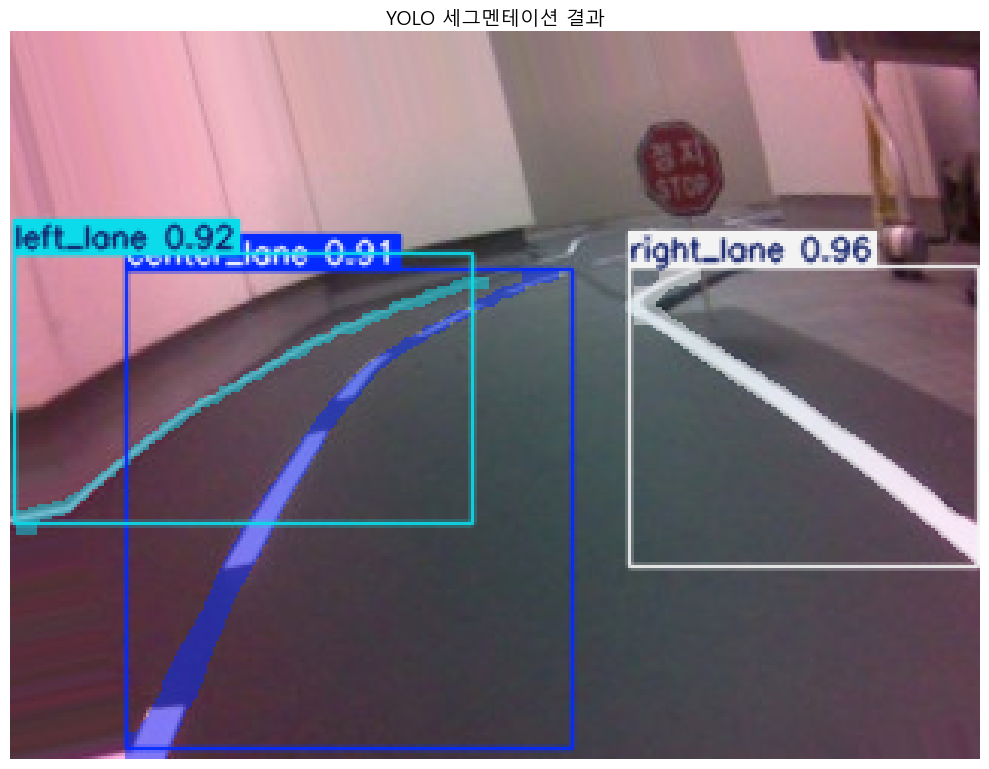

In [ ]:
# 결과 이미지를 BGR numpy ndarray로 반환(내부적으로 OpenCV를 사용하기 때문)
annotated_bgr = pred_results[0].plot(
    line_width=1,    # 바운딩 박스 선 두께
    font_size=5,    # 레이블 폰트 크기 (내부적으로 cv2 scale에 매핑, 한계 있음)
    conf=True,       # 신뢰도 표시 여부
    labels=True,     # 레이블 표시 여부
)
# BGR 이미지를 RGB로 변환 (OpenCV는 BGR, Matplotlib는 RGB)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

# Matplotlib으로 결과 이미지 표시
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(annotated_rgb)
ax.axis("off")
ax.set_title("YOLO 세그멘테이션 결과", fontsize=14)
plt.tight_layout()
plt.show()

##### 추론 시각화: 방법2 - matplotlib으로 마스크 직접 그리기

선택된 이미지: ../datasets/lane-seg/images/test\lane_train_080.jpg

image 1/1 d:\Work\ai\05-ai-model-development\projects\ai-model-development-v2\sec08\..\datasets\lane-seg\images\test\lane_train_080.jpg: 256x320 1 center_lane, 1 left_lane, 1 right_lane, 21.8ms
Speed: 0.6ms preprocess, 21.8ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 320)
Results saved to D:\Work\ai\05-ai-model-development\projects\ai-model-development-v2\sec08\runs\segment\06\predict


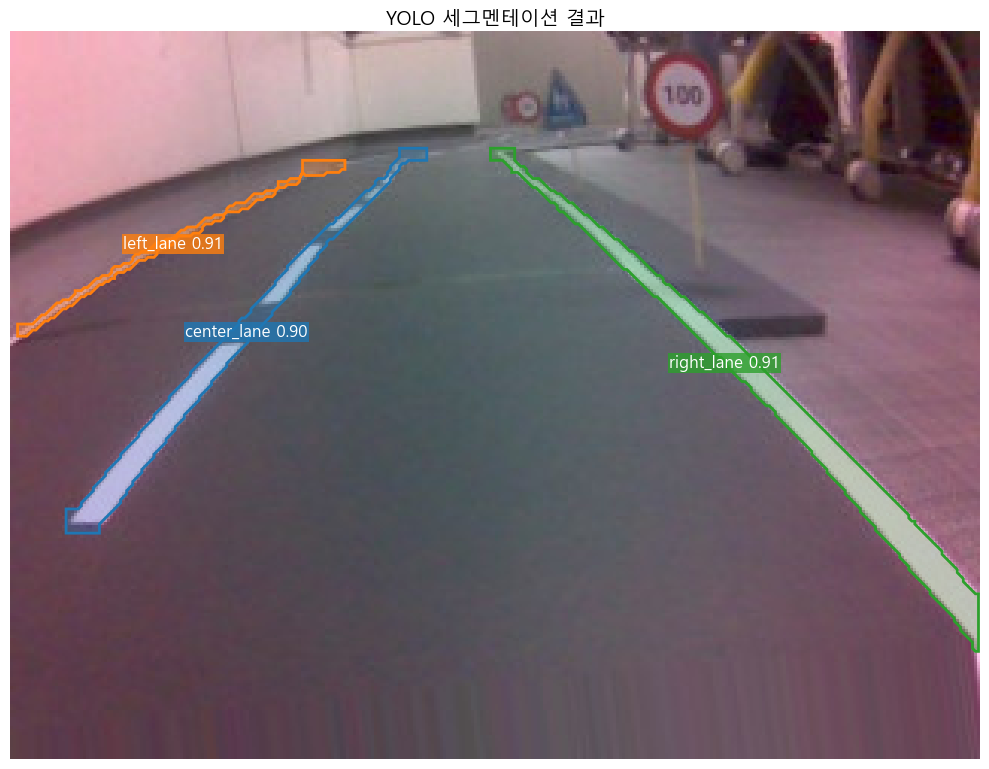

In [ ]:
# 테스트셋 이미지 목록에서 랜덤으로 한 장 선택
test_images = glob.glob(f"{DATASET_PATH}/images/test/*.jpg")
test_image = random.choice(test_images)
print(f"선택된 이미지: {test_image}")

# 추론
pred_results = best_model(                  # best_model(...)와 동일
    test_image,
    # conf=0.25,                            # 신뢰도 임계값 (confidence threshold)
    save=True,                              # 결과 이미지 저장
    project="06", # 결과 저장 폴더
    name="predict",                         # 결과 저장 폴더 이름
    exist_ok=True,                          # 결과 저장 폴더 덮어쓰기 여부
)

# 원본 이미지 로드
img = mpimg.imread(Path(test_image).resolve())

# matplotlib으로 마스크 직접 그리기
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis("off")
ax.set_title("YOLO 세그멘테이션 결과", fontsize=14)

# 탐지된 객체의 바운딩 박스 정보 추출
boxes = pred_results[0].boxes
# 탐지된 객체의 세그멘테이션 마스크 정보 추출
masks = pred_results[0].masks

# 클래스별 고유 색상 생성 
# tab10 컬러 맵: 범주형 데이터에 최적화된 10가지 뚜렷한 색상 제공
cmap = plt.colormaps.get_cmap("tab10")

# 폴리곤 마스크와 레이블 그리기
if masks is not None:
    # 탐지된 객체 수만큼 반복하여 폴리곤 마스크와 레이블 그리기
    for poly, box in zip(masks.xy, boxes):
        # 클래스 레이블 얻기
        class_id = int(box.cls)
        # 클래스 이름 추출
        class_name = best_model.names[class_id]
        # 신뢰도 추출
        confidence = float(box.conf)
        # 클래스 레이블로 색상 선택
        color = cmap(class_id)

        # 폴리곤 마스크 그리기
        polygon = patches.Polygon(
            poly, closed=True,
            # 폴리곤 내부를 반투명하게 채우기
            # *color[:3]: RGBA 튜플에서 RGB 값만 추출
            # 0.3: 투명도 (alpha) 값으로 폴리곤 내부를 반투명하게 채우기
            facecolor=(*color[:3], 0.3),
            # 폴리곤 외곽선 색상 설정
            edgecolor=color, 
            # 폴리곤 외곽선 두께 설정
            linewidth=2
        )
        # 폴리곤을 그래프에 추가
        ax.add_patch(polygon)

        # 레이블 텍스트 그리기 (폴리곤의 중앙에 위치)
        # poly는 (N, 2) 형태의 numpy 배열로, 각 행이 (x, y) 좌표를 나타냄
        # 모든 x 좌표의 평균 → 폴리곤 중심 x
        cx = poly[:, 0].mean()
        # 모든 y 좌표의 평균 → 폴리곤 중심 y
        cy = poly[:, 1].mean()
        
        # 클래스 이름과 신뢰도 레이블을 폴리곤의 중앙에 표시
        ax.text(
            cx, cy,  # 폴리곤 중심에 레이블 위치
            f"{class_name} {confidence:.2f}",  # 클래스 이름과 신뢰도 표시
            fontsize=12, color="white",  # 글자 크기와 색상
            ha="center", va="center",    # 가로/세로 중앙 정렬
            bbox={
                "facecolor":color, # 레이블 배경 색상 (바운딩 박스와 동일)
                "alpha":0.8, # 레이블 배경 투명도
                "pad":1,  # 레이블 배경과 글자 사이의 패딩
                "edgecolor":"none" # 레이블 배경 테두리 없음
            }
        )

plt.tight_layout()
plt.show()


업로드된 이미지를 추론해서 다운로드시키기

저장 완료: D:\Work\ai\05-ai-model-development\projects\ai-model-development-v2\sec08\runs\segment\06\predict\lane_train_009.jpg


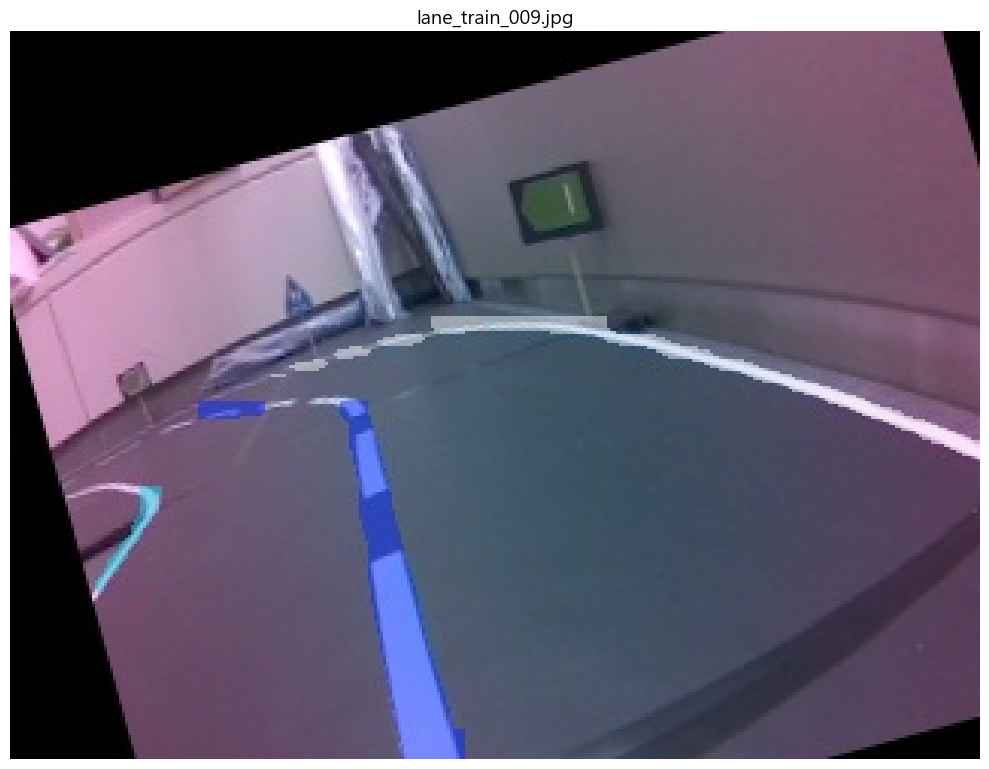

In [28]:
# 업로드된 이미지라고 가정
INPUT_PATH  = Path(f"{DATASET_PATH}/images/test/lane_train_009.jpg")
# 다운로드할 이미지라고 가정
OUTPUT_PATH = Path(f"runs/segment/06/predict/lane_train_009.jpg")

# 업로드된 파일의 바이트 배열 읽기
image_bytes = INPUT_PATH.read_bytes()

# 바이트 배열을 numpy ndarray로 변환
nparr        = np.frombuffer(image_bytes, np.uint8)

# OpenCV로 디코딩하여 BGR 순서의 이미지 얻기
img_bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

# 추론
result = best_model(img_bgr, verbose=False)

# result[0].plot(): 추론 결과가 그려진 이미지 반환 (BGR 순서의 numpy ndarray)
# cv.imencode(): JPEG 형식으로 인코딩
# success: 인코딩 성공 여부
# jpg_img: JPEG 형식으로 인코딩된 이미지 (numpy ndarray)
success, jpg_img       = cv2.imencode(".jpg", result[0].plot(boxes=False)) # boxes=False 옵션으로 바운딩 박스 제거
result_bytes = jpg_img.tobytes()

# 추론 결과를 파일로 다운로드
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_bytes(result_bytes)
print(f"저장 완료: {OUTPUT_PATH.resolve()}")

# 추론 결과 이미지 보기
img = mpimg.imread(str(OUTPUT_PATH))
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis("off")
ax.set_title("lane_train_009.jpg", fontsize=14)
plt.tight_layout()
plt.show()

실시간 비디오 영상 추론하고 시각화하기

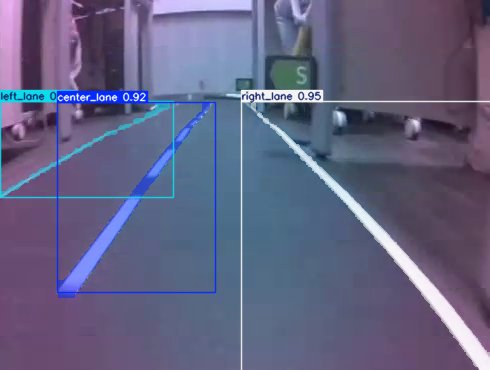

KeyboardInterrupt: 

In [32]:
# 실제로는 스트리밍으로 입력으로 프레임 얻기
VIDEO_PATH = Path("../datasets/videos/lane-seg.mp4")
frame = cv2.VideoCapture(str(VIDEO_PATH))

# 프레임 속도(FPS) 계산
fps = frame.get(cv2.CAP_PROP_FPS) or 30
print(f"FPS: {fps:.2f}")
frame_interval = 1 / fps

try:
    # 프레임 단위로 영상 처리
    while frame.isOpened():
        # 시작 시간 기록
        t0 = time.time()
        # 프레임 읽기
        # success: 프레임 읽기 성공 여부, frame_bgr: 읽은 프레임 (BGR 순서의 numpy ndarray)
        success, frame_bgr = frame.read()
        if not success:
            break

        # 추론 → JPEG bytes
        pred_results = best_model.predict(frame_bgr, verbose=False)
        
        # 결과 이미지를 BGR numpy ndarray로 반환(내부적으로 OpenCV를 사용하기 때문)
        annotated_bgr = pred_results[0].plot(
            line_width=1,    # 바운딩 박스 선 두께
            font_size=5,    # 레이블 폰트 크기 (내부적으로 cv2 scale에 매핑, 한계 있음)
            conf=True,       # 신뢰도 표시 여부
            labels=True,     # 레이블 표시 여부
        )
        # success: 인코딩 성공 여부, jpg_img: JPEG 형식으로 인코딩된 이미지 (numpy ndarray)
        success, jpg_img = cv2.imencode(".jpg", annotated_bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])

        # JPEG -> 바이트 배열로 변환
        jpg_bytes  = jpg_img.tobytes() 
        
        # 이전 프레임 지우고 노트북에 프레임 보여주기
        # wait=False: 즉시 출력 지움. 다음 프레임이 나타날 때까지 빈 화면이 잠깐 보임 (깜빡임 발생)
        # wait=True: 이전 프레임이 사라지지 않고 다음 프레임이 나타날 때까지 유지 (깜빡임 없음)
        clear_output(wait=True)
        display(IPImage(data=jpg_bytes, width=800))

        # 추론·표시에 걸린 시간만큼 sleep 차감
        elapsed = time.time() - t0
        wait = frame_interval - elapsed
        if wait > 0:
            time.sleep(wait)
finally:
    # 프레임 자원 해제
    frame.release()
